# 02 — Nominal SIMP Topology Optimization Demo

| | |
|---|---|
| **Pipeline position** | Modules 2 · 4 · 5 from implementation spec |
| **Prerequisites** | `01_fea_basics_demo.ipynb` (or equivalent FEA background) |
| **Dependencies** | `numpy`, `scipy`, `matplotlib` (standard scientific stack) |
| **Estimated runtime** | < 90 s for 60 × 20 mesh on a laptop |
| **Next notebook** | `03_metrology_ingestion.ipynb` — adds manufacturing uncertainty |

---

## What this notebook implements

This notebook builds the **nominal (deterministic) branch** of the robust topology optimization
pipeline. It produces an optimized density field that minimises structural compliance under a
volume-fraction constraint, *ignoring manufacturing uncertainty*. The resulting design will later
serve as the warm-start for the robust optimiser (Module 17).

### Modules covered

| Module | Name | Role here |
|--------|------|-----------|
| **2** | Core data structures | `Mesh2D`, `FEAProblem`, `DensityField`, `DesignState`, `ResultsBundle` |
| **4** | Deterministic linear elasticity FEA | Q4 stiffness assembly, solve *KU = F*, compliance & adjoint sensitivity |
| **5** | Nominal SIMP topology optimisation | SIMP interpolation, density filter, Optimality Criteria (OC) update loop |

---

## Mathematical overview

**Problem statement**

$$
\min_{\boldsymbol{\rho}} \quad C(\boldsymbol{\rho}) = \mathbf{F}^\top \mathbf{U}(\boldsymbol{\rho})
\qquad
\text{s.t.} \quad
\frac{1}{n_e}\sum_e \rho_e = V_f, \quad
\rho_e \in [\rho_{\min}, 1]
$$

**SIMP interpolation** (Solid Isotropic Material with Penalisation)

$$
E(\rho_e) = E_{\min} + \rho_e^p \bigl(E_0 - E_{\min}\bigr), \qquad p \geq 3
$$

**Adjoint compliance sensitivity** (via virtual work principle)

$$
\frac{\partial C}{\partial \rho_e} = -p\,\rho_e^{p-1}(E_0 - E_{\min})\,\mathbf{u}_e^\top \mathbf{k}_0 \mathbf{u}_e
$$

**Density filter** (checkerboard suppression, Bourdin 2001)

$$
\tilde{\rho}_e = \frac{\sum_f H_{ef}\,\rho_f}{\sum_f H_{ef}}, \qquad
H_{ef} = \max\!\bigl(0,\; r_{\min} - \|\mathbf{x}_e - \mathbf{x}_f\|\bigr)
$$

**Optimality Criteria (OC) update**

$$
\rho_e^{(k+1)} =
\operatorname{clip}\!\left(
\rho_e^{(k)} B_e^{\,\eta},\;
[\rho_e - m,\; \rho_e + m] \cap [\rho_{\min}, 1]
\right),
\qquad B_e = \frac{-\partial C/\partial \rho_e}{\lambda}
$$

where $\lambda$ is found by bisection to satisfy the volume constraint.

In [5]:
# ── Imports ────────────────────────────────────────────────────────────────────
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from dataclasses import dataclass, field
from typing import Optional, List, Tuple
import time
import warnings
warnings.filterwarnings('ignore')

np.set_printoptions(precision=6, suppress=True)
%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
print("Environment ready.")

Environment ready.


---
## Module 2 — Core Data Structures

All modules share typed objects with clear interfaces. The classes here are the 2-D specialisations
of the full 3-D counterparts defined in the production codebase. Using `@dataclass` enforces
explicit typing and makes serialisation straightforward.

> **Node / element numbering convention**  
> Node `(col, row)` → global index `col * (nely+1) + row`  
> Element `(col, row)` → global index `col * nely + row`  
> Both use **column-major** (y varies fastest), so density arrays reshape to `(nelx, nely)`.

In [6]:
# ── Module 2: Core Data Structures ─────────────────────────────────────────────

@dataclass
class Mesh2D:
    """
    Structured rectangular mesh of bilinear Q4 elements.

    Inputs
    ------
    nelx, nely : element counts in x- and y-directions
    lx, ly     : physical domain length (default: unit square)

    Outputs (properties)
    --------------------
    n_nodes, n_dofs, n_elements, hx, hy
    node_coords(), element_centers(), element_dofs(), all_element_dofs()
    """
    nelx: int
    nely: int
    lx: float = 1.0
    ly: float = 1.0

    def __post_init__(self):
        self.hx = self.lx / self.nelx
        self.hy = self.ly / self.nely

    # ── derived sizes ──────────────────────────────────────────────────────────
    @property
    def n_nodes(self) -> int:
        return (self.nelx + 1) * (self.nely + 1)

    @property
    def n_dofs(self) -> int:
        return 2 * self.n_nodes

    @property
    def n_elements(self) -> int:
        return self.nelx * self.nely

    # ── indexing helpers ───────────────────────────────────────────────────────
    def node_index(self, col: int, row: int) -> int:
        """Global node index from grid position (col, row)."""
        return col * (self.nely + 1) + row

    def element_index(self, col: int, row: int) -> int:
        """Global element index from grid position (col, row)."""
        return col * self.nely + row

    # ── geometry ───────────────────────────────────────────────────────────────
    def node_coords(self) -> np.ndarray:
        """All node coordinates, shape (n_nodes, 2)."""
        coords = np.zeros((self.n_nodes, 2))
        for col in range(self.nelx + 1):
            for row in range(self.nely + 1):
                coords[self.node_index(col, row)] = [col * self.hx, row * self.hy]
        return coords

    def element_centers(self) -> np.ndarray:
        """Centroid coordinates for every element, shape (n_elements, 2)."""
        centers = np.zeros((self.n_elements, 2))
        for col in range(self.nelx):
            for row in range(self.nely):
                centers[self.element_index(col, row)] = [
                    (col + 0.5) * self.hx,
                    (row + 0.5) * self.hy,
                ]
        return centers

    # ── DOF connectivity ───────────────────────────────────────────────────────
    def element_dofs(self, col: int, row: int) -> np.ndarray:
        """
        8 global DOF indices for element (col, row).
        Node order: SW → SE → NE → NW (counter-clockwise, positive Jacobian).
        DOF order : [u_SW, v_SW, u_SE, v_SE, u_NE, v_NE, u_NW, v_NW]
        """
        n1 = self.node_index(col,     row    )   # SW
        n2 = self.node_index(col + 1, row    )   # SE
        n3 = self.node_index(col + 1, row + 1)   # NE
        n4 = self.node_index(col,     row + 1)   # NW
        return np.array([
            2*n1, 2*n1+1,
            2*n2, 2*n2+1,
            2*n3, 2*n3+1,
            2*n4, 2*n4+1,
        ], dtype=int)

    def all_element_dofs(self) -> np.ndarray:
        """Precomputed DOF array for all elements, shape (n_elements, 8)."""
        edofs = np.zeros((self.n_elements, 8), dtype=int)
        for col in range(self.nelx):
            for row in range(self.nely):
                edofs[self.element_index(col, row)] = self.element_dofs(col, row)
        return edofs


@dataclass
class FEAProblem:
    """
    Encapsulates one deterministic FEA problem (Module 4 inputs).

    Inputs
    ------
    mesh         : Mesh2D
    E0           : Young's modulus of solid phase
    Emin         : Young's modulus of void phase (prevents stiffness singularity)
    nu           : Poisson's ratio (plane stress)
    penal        : SIMP penalty exponent p ≥ 3
    fixed_dofs   : DOF indices with Dirichlet = 0
    free_dofs    : complement of fixed_dofs
    force_vector : global Neumann load vector F, shape (n_dofs,)
    """
    mesh:         Mesh2D
    E0:           float
    Emin:         float
    nu:           float
    penal:        float
    fixed_dofs:   np.ndarray
    free_dofs:    np.ndarray
    force_vector: np.ndarray

    def __post_init__(self):
        assert 0 < self.Emin < self.E0,  "Need Emin < E0"
        assert 0 < self.nu < 0.5,         "nu must be in (0, 0.5) for plane stress"
        assert self.penal >= 1.0,          "SIMP penalty must be ≥ 1"


@dataclass
class DensityField:
    """
    Element density field ρ ∈ [ρ_min, 1]^{n_elem} (Module 2 / 5).

    Tracks both the design variables (before filter) and the physical
    densities (after filter) that are passed to FEA.
    """
    rho:            np.ndarray           # physical densities (after filter)
    rho_unfiltered: Optional[np.ndarray] = None   # design variables
    rho_min:        float = 1e-3

    @property
    def volume_fraction(self) -> float:
        return float(np.mean(self.rho))


@dataclass
class DesignState:
    """Snapshot of the optimisation state at one iteration."""
    iteration:   int
    density:     DensityField
    compliance:  float
    displacement: np.ndarray
    sensitivity:  np.ndarray        # ∂C/∂ρ (after filter chain rule)
    change:      float = 1.0        # max |Δρ| from previous iteration


@dataclass
class ResultsBundle:
    """
    Complete output of one SIMP run (Module 2 ResultsBundle).

    Outputs
    -------
    final_state        : DesignState at last iteration
    compliance_history : C at every iteration
    volume_history     : volume fraction at every iteration
    change_history     : max |Δρ| at every iteration
    iterations         : total iterations run
    converged          : whether tol was reached
    cpu_time           : wall-clock seconds
    """
    final_state:        DesignState
    compliance_history: List[float] = field(default_factory=list)
    volume_history:     List[float] = field(default_factory=list)
    change_history:     List[float] = field(default_factory=list)
    iterations:         int  = 0
    converged:          bool = False
    cpu_time:           float = 0.0

    @property
    def n_iterations(self) -> int:
        return len(self.compliance_history)


print("Data structures defined: Mesh2D, FEAProblem, DensityField, DesignState, ResultsBundle")

Data structures defined: Mesh2D, FEAProblem, DensityField, DesignState, ResultsBundle


---
## Module 4 — Deterministic Linear Elasticity FEA

### Q4 element stiffness (bilinear isoparametric, plane stress)

The reference element lives in $[-1,1]^2$. A unit physical element $[0,1]^2$ maps to it via
$x = (\xi+1)/2$, giving Jacobian $\mathbf{J} = \tfrac{1}{2}\mathbf{I}$ and $\det J = \tfrac{1}{4}$.

$$
\mathbf{k}_e = \int_{-1}^{1}\int_{-1}^{1}
\mathbf{B}^\top \mathbf{D} \mathbf{B}\,\det\mathbf{J}\,d\xi\,d\eta
\approx \sum_{i,j} w_i w_j \mathbf{B}^\top(\xi_i,\eta_j)\,\mathbf{D}\,\mathbf{B}(\xi_i,\eta_j)\,\det\mathbf{J}
$$

Integrated with 2 × 2 Gauss quadrature (exact for bilinear shape functions).

Plane stress constitutive matrix:
$$
\mathbf{D} = \frac{E}{1-\nu^2}
\begin{bmatrix}
1 & \nu & 0 \\
\nu & 1 & 0 \\
0 & 0 & \frac{1-\nu}{2}
\end{bmatrix}
$$

In [7]:
# ── Module 4: Q4 Element Stiffness ─────────────────────────────────────────────

def compute_q4_stiffness(E: float, nu: float) -> np.ndarray:
    """
    Q4 bilinear element stiffness matrix, plane stress, unit square element.

    Inputs
    ------
    E  : Young's modulus
    nu : Poisson's ratio

    Outputs
    -------
    ke : (8, 8) element stiffness matrix
         DOF order: [u_SW, v_SW, u_SE, v_SE, u_NE, v_NE, u_NW, v_NW]

    Concepts
    --------
    Isoparametric FEM, Gauss quadrature, strain-displacement matrix B,
    plane-stress constitutive law D.
    """
    # Plane-stress constitutive matrix D
    c = E / (1.0 - nu**2)
    D = c * np.array([
        [1.0,  nu,           0.0       ],
        [nu,   1.0,          0.0       ],
        [0.0,  0.0,  (1.0 - nu) / 2.0 ],
    ])

    # 2×2 Gauss points and weights (exact for bilinear shape functions)
    g = 1.0 / np.sqrt(3.0)
    gauss_pts = [(-g, -g), (g, -g), (g, g), (-g, g)]

    # For unit square [0,1]² ↔ reference [-1,1]²:
    #   x = (ξ+1)/2  →  J = ½I  →  det J = ¼  →  J⁻¹ = 2I
    det_J = 0.25

    ke = np.zeros((8, 8))
    for xi, eta in gauss_pts:
        # Bilinear shape function natural derivatives
        # N = [N_SW, N_SE, N_NE, N_NW]
        dN_dxi  = 0.25 * np.array([-(1 - eta),  (1 - eta), (1 + eta), -(1 + eta)])
        dN_deta = 0.25 * np.array([-(1 - xi),  -(1 + xi),  (1 + xi),  (1 - xi) ])

        # Physical derivatives: (J⁻¹ = 2I for unit element)
        dN_dx = 2.0 * dN_dxi
        dN_dy = 2.0 * dN_deta

        # Strain-displacement matrix B (3×8)
        #   row 0: ε_xx = ∂u/∂x
        #   row 1: ε_yy = ∂v/∂y
        #   row 2: γ_xy = ∂u/∂y + ∂v/∂x
        B = np.zeros((3, 8))
        for i in range(4):
            B[0, 2*i    ] = dN_dx[i]
            B[1, 2*i + 1] = dN_dy[i]
            B[2, 2*i    ] = dN_dy[i]   # γ_xy contribution from u
            B[2, 2*i + 1] = dN_dx[i]   # γ_xy contribution from v

        # Gauss weight = 1 for both directions (2×2 rule with w_i = 1)
        ke += B.T @ D @ B * det_J

    return ke


# ── Quick sanity check: ke must be symmetric and positive semi-definite ────────
k0_test = compute_q4_stiffness(E=1.0, nu=0.3)
assert k0_test.shape == (8, 8),                    "Wrong shape"
assert np.allclose(k0_test, k0_test.T, atol=1e-12), "ke not symmetric"
eigs = np.linalg.eigvalsh(k0_test)
# 3 zero eigenvalues (rigid body modes: 2 translations + 1 rotation)
assert np.sum(eigs < -1e-10) == 0, "ke has negative eigenvalues"
print(f"k0 eigenvalues (should have 3 near-zero):")
print(f"  {np.sort(eigs)}")

k0 eigenvalues (should have 3 near-zero):
  [0.       0.       0.       0.494505 0.494505 0.769231 0.769231 1.428571]


### Global stiffness assembly & solver

The global stiffness matrix is assembled in COO (coordinate) format and converted to CSR for
efficient sparse-direct solving:

$$
\mathbf{K} = \sum_e E(\rho_e)\,\mathbf{k}_0
$$

Boundary conditions are enforced by reducing the system to the free DOFs only (no
penalty/large-number approach, which can degrade conditioning).

In [8]:
# ── Module 4: Global Stiffness Assembly ────────────────────────────────────────

def assemble_stiffness(
    mesh:    Mesh2D,
    problem: FEAProblem,
    rho:     np.ndarray,
    edofs:   np.ndarray,
    k0:      np.ndarray,
) -> csr_matrix:
    """
    Assemble global stiffness with SIMP interpolation (vectorised COO build).

    Inputs
    ------
    mesh    : Mesh2D
    problem : FEAProblem  →  E0, Emin, penal
    rho     : (n_elem,) physical density field (after density filter)
    edofs   : (n_elem, 8) precomputed element DOF indices
    k0      : (8, 8) unit element stiffness (E=1)

    Outputs
    -------
    K : (n_dofs, n_dofs) sparse CSR global stiffness matrix

    Concepts
    --------
    SIMP: E(ρ_e) = Emin + ρ_e^p · (E0 − Emin)
    Global stiffness: K = Σ_e  E(ρ_e) · k0
    """
    n_elem = mesh.n_elements

    # SIMP material interpolation  ──────────────────────────────────────────────
    Ee = problem.Emin + rho**problem.penal * (problem.E0 - problem.Emin)
    # Ee shape: (n_elem,)

    # Scale unit stiffness by each element's Young's modulus
    # ke_all[e, i, j] = Ee[e] * k0[i, j]
    ke_all = Ee[:, np.newaxis, np.newaxis] * k0[np.newaxis, :, :]   # (n_elem, 8, 8)

    # Build COO triplets (64 entries per element) ───────────────────────────────
    # Row indices: repeat each row DOF 8 times  →  (n_elem, 8, 8)
    rows_mat = np.tile(edofs[:, :, np.newaxis], (1, 1, 8))   # (n_elem, 8, 8)
    cols_mat = np.tile(edofs[:, np.newaxis, :], (1, 8, 1))   # (n_elem, 8, 8)

    K = csr_matrix(
        (ke_all.ravel(), (rows_mat.ravel(), cols_mat.ravel())),
        shape=(mesh.n_dofs, mesh.n_dofs),
    )
    return K


def solve_fea(K: csr_matrix, problem: FEAProblem) -> np.ndarray:
    """
    Solve K U = F for free DOFs, return full displacement vector.

    Inputs
    ------
    K       : global stiffness matrix
    problem : FEAProblem  →  free_dofs, force_vector

    Outputs
    -------
    U : (n_dofs,) displacement vector (zero at fixed DOFs)

    Concepts
    --------
    Dirichlet BCs via DOF elimination (reduced system), sparse direct solve.
    """
    U = np.zeros(problem.mesh.n_dofs)
    free = problem.free_dofs

    K_free = K[np.ix_(free, free)]
    F_free = problem.force_vector[free]

    U[free] = spsolve(K_free, F_free)
    return U


def compute_compliance_and_sensitivity(
    U:       np.ndarray,
    problem: FEAProblem,
    rho:     np.ndarray,
    edofs:   np.ndarray,
    k0:      np.ndarray,
) -> Tuple[float, np.ndarray]:
    """
    Compute total compliance and adjoint sensitivity w.r.t. element densities.

    Inputs
    ------
    U       : (n_dofs,) global displacement vector from FEA solve
    problem : FEAProblem  →  E0, Emin, penal
    rho     : (n_elem,) physical density field ρ̃
    edofs   : (n_elem, 8) element DOF indices
    k0      : (8, 8) unit element stiffness

    Outputs
    -------
    C  : scalar total compliance  C = F^T U
    dc : (n_elem,) sensitivity ∂C/∂ρ̃_e  (all values ≤ 0)

    Theory
    ------
    C = Σ_e E(ρ_e) · u_e^T k0 u_e

    Adjoint method (λ = −U):
      ∂C/∂ρ_e = −p ρ_e^{p−1} (E0 − Emin) · u_e^T k0 u_e

    The negative sign: adding material (↑ρ_e) ↑ stiffness → ↓ compliance.
    """
    p    = problem.penal
    E0   = problem.E0
    Emin = problem.Emin

    # Element displacement vectors: u_e ∈ ℝ^8 for each element
    u_e = U[edofs]                                       # (n_elem, 8)

    # Element strain energy: u_e^T k0 u_e  (vectorised via einsum)
    strain_energy = np.einsum('ei,ij,ej->e', u_e, k0, u_e)   # (n_elem,)

    # Total compliance
    Ee = Emin + rho**p * (E0 - Emin)
    C  = float(np.dot(Ee, strain_energy))

    # Sensitivity ∂C/∂ρ̃_e  (always ≤ 0)
    dc = -p * rho**(p - 1) * (E0 - Emin) * strain_energy

    return C, dc


print("Module 4 functions defined: assemble_stiffness, solve_fea, compute_compliance_and_sensitivity")

Module 4 functions defined: assemble_stiffness, solve_fea, compute_compliance_and_sensitivity


---
## Module 5 — Nominal SIMP Topology Optimisation

### Density filter (checkerboard suppression)

Without regularisation, the discrete SIMP problem has a known tendency to produce checkerboard
patterns (alternating solid/void elements that appear stiff due to finite-element locking) and
mesh-dependent solutions. The density filter smooths the design field:

$$
\tilde{\rho}_e = \frac{\sum_f H_{ef}\,\rho_f}{\sum_f H_{ef}}
$$

The gradient of the filtered field w.r.t. the raw design variables (chain rule) is:

$$
\frac{\partial C}{\partial \rho_e} = \sum_f \frac{\partial C}{\partial \tilde{\rho}_f}\,
\frac{H_{fe}}{\sum_g H_{fg}}
\quad\Longleftrightarrow\quad
\mathbf{dc}_{\text{design}} = \mathbf{H}^\top \!\left(\frac{\mathbf{dc}_{\text{phys}}}{\mathbf{H}_s}\right)
$$

In [9]:
# ── Module 5: Density Filter ────────────────────────────────────────────────────

def build_filter_weights(
    mesh:  Mesh2D,
    r_min: float,
) -> Tuple[csr_matrix, np.ndarray]:
    """
    Build the density filter weight matrix H.

    Inputs
    ------
    mesh  : Mesh2D  (element centres extracted internally)
    r_min : filter radius in physical units

    Outputs
    -------
    H  : (n_elem, n_elem) sparse CSR filter matrix
    Hs : (n_elem,) row sums of H (normalisation denominators)

    Weight kernel: H_{ef} = max(0, r_min − ‖x_e − x_f‖)
    Covariance concept: this is a cone kernel — analogous to the linear covariance
    kernels used later in Module 7 (geometric error fitting).
    """
    centers = mesh.element_centers()   # (n_elem, 2)
    n_elem  = mesh.n_elements

    # All pairwise distances  (fine for n_elem < ~10 000)
    diff = centers[:, np.newaxis, :] - centers[np.newaxis, :, :]   # (n,n,2)
    dist = np.linalg.norm(diff, axis=2)                             # (n,n)

    # Cone kernel: positive where dist < r_min
    H_dense = np.maximum(0.0, r_min - dist)
    Hs      = H_dense.sum(axis=1)                                   # (n_elem,)

    # Store as sparse for memory efficiency with large meshes
    I_idx, J_idx = np.where(H_dense > 0)
    H = csr_matrix(
        (H_dense[I_idx, J_idx], (I_idx, J_idx)),
        shape=(n_elem, n_elem),
    )
    return H, Hs


def apply_density_filter(
    rho: np.ndarray,
    H:   csr_matrix,
    Hs:  np.ndarray,
) -> np.ndarray:
    """
    Apply density filter: ρ̃_e = (H ρ)_e / Hs_e

    Inputs : rho (n_elem,) design variables, H, Hs from build_filter_weights
    Outputs: rho_filtered (n_elem,) physical densities passed to FEA
    """
    return (H @ rho) / Hs


def filter_sensitivity_chain_rule(
    dc_phys: np.ndarray,
    H:       csr_matrix,
    Hs:      np.ndarray,
) -> np.ndarray:
    """
    Back-propagate sensitivity from physical (filtered) to design (raw) field.

    dc_design = H^T (dc_phys / Hs)

    This is the chain rule through the linear density filter:
      ∂C/∂ρ_e = Σ_f (∂C/∂ρ̃_f) · H_{fe} / Hs_f
    """
    return H.T @ (dc_phys / Hs)


print("Density filter functions defined: build_filter_weights, apply_density_filter, filter_sensitivity_chain_rule")

Density filter functions defined: build_filter_weights, apply_density_filter, filter_sensitivity_chain_rule


### Optimality Criteria (OC) update

OC exploits the special structure of compliance minimisation to build a fast, gradient-based
density update that automatically satisfies the volume constraint via bisection on the Lagrange
multiplier $\lambda$.

At the optimum: $-\partial C/\partial \rho_e = \lambda \,v_e$ (KKT stationarity).  
The *optimality factor* $B_e = -\partial C/\partial \rho_e \;/\; \lambda$ measures how far
each element is from the KKT condition. Elements with $B_e > 1$ want more material;
$B_e < 1$ want less.

The move limit $m$ acts like a trust-region radius and is crucial for convergence.

In [10]:
# ── Module 5: Optimality Criteria Update ───────────────────────────────────────

def oc_update(
    rho:     np.ndarray,
    dc:      np.ndarray,
    volfrac: float,
    move:    float = 0.2,
    eta:     float = 0.5,
    rho_min: float = 1e-3,
) -> np.ndarray:
    """
    Optimality Criteria density update with bisection for volume constraint.

    Inputs
    ------
    rho     : (n_elem,) current density field ρ^(k)
    dc      : (n_elem,) sensitivity ∂C/∂ρ_e  (all ≤ 0)
    volfrac : target volume fraction Vf
    move    : move limit m  (max |Δρ_e| per iteration, default 0.2)
    eta     : OC damping exponent (default 0.5, Sigmund 2001)
    rho_min : minimum allowable density (void void, default 1e-3)

    Outputs
    -------
    rho_new : (n_elem,) updated density field ρ^(k+1)

    Algorithm
    ---------
    B_e = −dc_e / λ          (optimality factor, ≥ 0 since dc ≤ 0)
    ρ_e^{k+1} = clip(ρ_e · B_e^η,  [ρ_e − m, ρ_e + m] ∩ [ρ_min, 1])
    λ found by bisection such that mean(ρ_new) = Vf

    Concepts: KKT conditions, Lagrange multiplier, bisection, trust region.
    """

    def _apply(lam: float) -> np.ndarray:
        """Apply OC formula for a given Lagrange multiplier lam."""
        # B_e = −dc_e / lam  (dc ≤ 0, lam > 0  →  B_e ≥ 0)
        B_e = np.maximum(0.0, -dc / lam)
        rho_cand = rho * B_e**eta
        # Clip to move limits ∩ [rho_min, 1]
        lo = np.maximum(rho_min, rho - move)
        hi = np.minimum(1.0,     rho + move)
        return np.clip(rho_cand, lo, hi)

    # Bisection on λ to enforce volume constraint Σρ_e / n_elem = Vf
    l_lo, l_hi = 1e-12, 1e12
    for _ in range(60):   # 60 iters → relative tolerance ~2^{-60} ≈ 1e-18
        l_mid = 0.5 * (l_lo + l_hi)
        rho_new = _apply(l_mid)
        if rho_new.mean() > volfrac:
            l_lo = l_mid   # volume too high → increase λ (penalise material)
        else:
            l_hi = l_mid   # volume too low  → decrease λ

    return _apply(0.5 * (l_lo + l_hi))


print("OC update defined.")

OC update defined.


### Main SIMP optimisation loop

The five steps per iteration:

1. **Filter** design variables → physical densities $\tilde{\boldsymbol{\rho}}$
2. **Assemble** $\mathbf{K}(\tilde{\boldsymbol{\rho}})$ and **solve** $\mathbf{K}\mathbf{U}=\mathbf{F}$
3. **Sensitivity** $\partial C / \partial \tilde{\rho}_e$ (adjoint method)
4. **Chain rule** back through filter → $\partial C / \partial \rho_e$
5. **OC update** → new design variables $\boldsymbol{\rho}^{(k+1)}$

Convergence is declared when $\|\boldsymbol{\rho}^{(k+1)} - \boldsymbol{\rho}^{(k)}\|_\infty < \texttt{tol}$.

In [11]:
# ── Module 5: SIMP Optimisation Loop ───────────────────────────────────────────

def run_simp(
    mesh:     Mesh2D,
    problem:  FEAProblem,
    volfrac:  float,
    r_min:    float,
    max_iter: int   = 200,
    tol:      float = 1e-3,
    move:     float = 0.2,
    verbose:  bool  = True,
) -> ResultsBundle:
    """
    Nominal SIMP topology optimisation (Module 5).

    Solves:
        min  C(ρ) = F^T U(ρ)
        s.t. mean(ρ) = Vf,   ρ_min ≤ ρ_e ≤ 1

    Inputs
    ------
    mesh     : Mesh2D
    problem  : FEAProblem  (BCs, material, SIMP params)
    volfrac  : volume fraction constraint Vf ∈ (0, 1)
    r_min    : density filter radius (physical units)
    max_iter : maximum OC iterations
    tol      : convergence tolerance on max density change
    move     : OC move limit per iteration
    verbose  : print progress every 5 iterations

    Outputs
    -------
    ResultsBundle: final_state, compliance_history, volume_history,
                   change_history, iterations, converged, cpu_time

    Concepts
    --------
    SIMP interpolation, density filter, adjoint sensitivity, OC update,
    KKT conditions, volume constraint enforcement via bisection.
    """
    t0    = time.time()
    n_elem = mesh.n_elements

    # Precompute expensive quantities once ──────────────────────────────────────
    edofs = mesh.all_element_dofs()                   # (n_elem, 8)
    k0    = compute_q4_stiffness(1.0, problem.nu)     # unit element stiffness
    H, Hs = build_filter_weights(mesh, r_min)         # filter matrix

    # Initialise: uniform density = target volume fraction ──────────────────────
    rho = volfrac * np.ones(n_elem)

    # History storage ───────────────────────────────────────────────────────────
    compliance_hist, volume_hist, change_hist = [], [], []
    C, dc, U = 0.0, np.zeros(n_elem), np.zeros(mesh.n_dofs)

    if verbose:
        header = f"{'Iter':>5}  {'Compliance':>14}  {'VolFrac':>9}  {'MaxΔρ':>10}"
        print(header)
        print('─' * len(header))

    for it in range(1, max_iter + 1):
        rho_prev = rho.copy()

        # ── Step 1: Density filter  ρ → ρ̃ ──────────────────────────────────
        rho_phys = apply_density_filter(rho, H, Hs)

        # ── Step 2: FEA (assemble K, solve KU = F) ────────────────────────
        K = assemble_stiffness(mesh, problem, rho_phys, edofs, k0)
        U = solve_fea(K, problem)

        # ── Step 3: Compliance and physical sensitivity ────────────────────
        C, dc_phys = compute_compliance_and_sensitivity(U, problem, rho_phys, edofs, k0)

        # ── Step 4: Chain rule through density filter ──────────────────────
        dc = filter_sensitivity_chain_rule(dc_phys, H, Hs)

        # ── Step 5: OC update of design variables ─────────────────────────
        rho = oc_update(rho, dc, volfrac, move=move)

        # ── Bookkeeping ───────────────────────────────────────────────────
        change = float(np.max(np.abs(rho - rho_prev)))
        vf     = float(rho_phys.mean())
        compliance_hist.append(C)
        volume_hist.append(vf)
        change_hist.append(change)

        if verbose and (it % 5 == 0 or it == 1):
            print(f"{it:>5}  {C:>14.4f}  {vf:>9.6f}  {change:>10.6f}")

        # ── Convergence ───────────────────────────────────────────────────
        if change < tol and it >= 5:
            if verbose:
                print(f"\n✓ Converged at iteration {it}  (max|Δρ| = {change:.2e})")
            break
    else:
        if verbose:
            print(f"\n⚠ Max iterations ({max_iter}) reached  (max|Δρ| = {change:.2e})")

    final = DesignState(
        iteration    = it,
        density      = DensityField(rho=rho_phys, rho_unfiltered=rho),
        compliance   = C,
        displacement = U,
        sensitivity  = dc,
        change       = change,
    )
    return ResultsBundle(
        final_state        = final,
        compliance_history = compliance_hist,
        volume_history     = volume_hist,
        change_history     = change_hist,
        iterations         = it,
        converged          = change < tol,
        cpu_time           = time.time() - t0,
    )


print("SIMP loop defined: run_simp")

SIMP loop defined: run_simp


---
## Visualisation Helpers

In [12]:
# ── Visualisation Utilities ─────────────────────────────────────────────────────

def plot_topology(
    rho:   np.ndarray,
    mesh:  Mesh2D,
    title: str = "Topology",
    ax    = None,
) -> None:
    """
    Render density field as a grayscale image.
    ρ = 1 (solid) → black;  ρ = 0 (void) → white.

    rho is stored column-major: rho[col*nely + row] = ρ at (col, row).
    Reshape to (nelx, nely), transpose for image axes (y up).
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4))
    rho_2d = rho.reshape(mesh.nelx, mesh.nely).T   # (nely, nelx), y=0 at bottom
    im = ax.imshow(
        rho_2d, cmap='gray_r', vmin=0, vmax=1,
        origin='lower', aspect='equal',
        extent=[0, mesh.nelx, 0, mesh.nely],
    )
    plt.colorbar(im, ax=ax, label='Density ρ', fraction=0.03)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('x (elements)')
    ax.set_ylabel('y (elements)')


def plot_convergence(results: ResultsBundle, figsize: tuple = (13, 4)) -> None:
    """Plot compliance, volume fraction, and max density change histories."""
    iters = range(1, results.n_iterations + 1)
    fig, axes = plt.subplots(1, 3, figsize=figsize)

    # Compliance
    axes[0].semilogy(iters, results.compliance_history, 'b-', linewidth=1.5)
    axes[0].set_xlabel('Iteration')
    axes[0].set_ylabel('Compliance C')
    axes[0].set_title('Compliance (log scale)')
    axes[0].grid(True, alpha=0.3)

    # Volume fraction
    axes[1].plot(iters, results.volume_history, 'r-', linewidth=1.5)
    axes[1].axhline(
        results.final_state.density.volume_fraction,
        color='r', linestyle='--', alpha=0.5, label=f"Final = {results.volume_history[-1]:.4f}",
    )
    axes[1].set_xlabel('Iteration')
    axes[1].set_ylabel('Volume fraction')
    axes[1].set_title('Volume Fraction')
    axes[1].set_ylim(0, 1)
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)

    # Max density change
    axes[2].semilogy(iters, results.change_history, 'g-', linewidth=1.5)
    axes[2].axhline(1e-3, color='k', linestyle=':', alpha=0.5, label='tol = 1e-3')
    axes[2].set_xlabel('Iteration')
    axes[2].set_ylabel('max |Δρ|')
    axes[2].set_title('Convergence (max density change)')
    axes[2].legend(fontsize=9)
    axes[2].grid(True, alpha=0.3)

    fig.suptitle(
        f"SIMP: {results.iterations} iters | "
        f"Final C = {results.compliance_history[-1]:.4f} | "
        f"CPU = {results.cpu_time:.1f}s | "
        f"{'Converged ✓' if results.converged else 'Not converged ✗'}",
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()


print("Visualisation helpers defined: plot_topology, plot_convergence")

Visualisation helpers defined: plot_topology, plot_convergence


---
## Test Case 1 — MBB Beam (Half Model, Symmetry)

The **MBB beam** (Messerschmitt–Bölkow–Blohm) is the canonical topology optimisation benchmark.
A simply-supported beam is loaded at mid-span. By symmetry, only the left half is modelled:

```
  F↓
  ╔═══════════════════════╗
  ║        nelx × nely    ║
  ╚═══════════════════════╝
  |←── u=0 (sym) ──╔      ╔ v=0 (right support)
```

**Boundary conditions (half model)**
- Left edge  (x = 0): horizontal DOF $u = 0$ (symmetry condition)
- Bottom-right corner: vertical DOF $v = 0$ (simple support)
- Top-left corner: downward unit force $F_y = -1$

In [13]:
# ── Problem Definitions ─────────────────────────────────────────────────────────

def make_mbb_problem(
    nelx:  int   = 60,
    nely:  int   = 20,
    E0:    float = 1.0,
    nu:    float = 0.3,
    Emin:  float = 1e-9,
    penal: float = 3.0,
) -> Tuple[Mesh2D, FEAProblem]:
    """
    MBB beam half-model: symmetry at left, support at bottom-right, load at top-left.

    Inputs : mesh parameters + material constants
    Outputs: (Mesh2D, FEAProblem) ready for run_simp
    """
    mesh = Mesh2D(nelx=nelx, nely=nely)
    ndof = mesh.n_dofs

    F = np.zeros(ndof)
    top_left = mesh.node_index(0, nely)
    F[2*top_left + 1] = -1.0       # unit downward force

    # Symmetry: fix u at all left-edge nodes
    left_nodes = [mesh.node_index(0, row) for row in range(nely + 1)]
    fixed_u    = [2*n for n in left_nodes]

    # Support: fix v at bottom-right corner
    br_node  = mesh.node_index(nelx, 0)
    fixed_v  = [2*br_node + 1]

    fixed_dofs = np.array(fixed_u + fixed_v, dtype=int)
    free_dofs  = np.setdiff1d(np.arange(ndof), fixed_dofs)

    problem = FEAProblem(
        mesh=mesh, E0=E0, Emin=Emin, nu=nu, penal=penal,
        fixed_dofs=fixed_dofs, free_dofs=free_dofs, force_vector=F,
    )
    return mesh, problem


def make_cantilever_problem(
    nelx:  int   = 60,
    nely:  int   = 40,
    E0:    float = 1.0,
    nu:    float = 0.3,
    Emin:  float = 1e-9,
    penal: float = 3.0,
) -> Tuple[Mesh2D, FEAProblem]:
    """
    Cantilever beam: clamped left wall, point load at mid-height of right edge.

    ```
    ╔═══════════════════════════╗
    ║                           ║  → F (mid-right)
    ║    nelx × nely            ║
    ╚═══════════════════════════╝
    ||← fixed (u=v=0)
    ```

    Inputs : mesh parameters + material constants
    Outputs: (Mesh2D, FEAProblem) ready for run_simp
    """
    mesh = Mesh2D(nelx=nelx, nely=nely)
    ndof = mesh.n_dofs

    F = np.zeros(ndof)
    mid_right = mesh.node_index(nelx, nely // 2)
    F[2*mid_right + 1] = -1.0      # unit downward force at mid-right

    left_nodes = [mesh.node_index(0, row) for row in range(nely + 1)]
    fixed_dofs = np.array(
        [dof for n in left_nodes for dof in (2*n, 2*n+1)],
        dtype=int,
    )
    free_dofs = np.setdiff1d(np.arange(ndof), fixed_dofs)

    problem = FEAProblem(
        mesh=mesh, E0=E0, Emin=Emin, nu=nu, penal=penal,
        fixed_dofs=fixed_dofs, free_dofs=free_dofs, force_vector=F,
    )
    return mesh, problem


print("Problem factories defined: make_mbb_problem, make_cantilever_problem")

Problem factories defined: make_mbb_problem, make_cantilever_problem


---
## Run 1: MBB Beam (60 × 20 elements, Vf = 0.5)

In [14]:
# ── MBB Beam Optimisation ───────────────────────────────────────────────────────
NELX, NELY   = 60, 20
VOLFRAC_MBB  = 0.5
RMIN_MBB     = 1.5     # filter radius in element units

mesh_mbb, prob_mbb = make_mbb_problem(
    nelx=NELX, nely=NELY,
    E0=1.0, nu=0.3, Emin=1e-9, penal=3.0,
)

print(f"Mesh:     {mesh_mbb.nelx} × {mesh_mbb.nely}  ({mesh_mbb.n_elements} elements, {mesh_mbb.n_dofs} DOFs)")
print(f"Volfrac:  {VOLFRAC_MBB}   Filter radius: {RMIN_MBB} elements")
print()

results_mbb = run_simp(
    mesh     = mesh_mbb,
    problem  = prob_mbb,
    volfrac  = VOLFRAC_MBB,
    r_min    = RMIN_MBB,
    max_iter = 200,
    tol      = 1e-3,
    move     = 0.2,
    verbose  = True,
)

print(f"\nTotal CPU time: {results_mbb.cpu_time:.2f} s")

Mesh:     60 × 20  (1200 elements, 2562 DOFs)
Volfrac:  0.5   Filter radius: 1.5 elements

 Iter      Compliance    VolFrac       MaxΔρ
────────────────────────────────────────────
    1       1007.0221   0.500000    0.105454
    5        924.2523   0.505417    0.041278
   10        867.4228   0.510597    0.038575
   15        833.9903   0.514796    0.036524
   20        816.1700   0.517407    0.032735
   25        806.1429   0.519025    0.028182
   30        799.8544   0.520135    0.026653
   35        795.5351   0.520948    0.023282
   40        792.4152   0.521567    0.021947
   45        790.1561   0.522047    0.019248
   50        788.4586   0.522431    0.017275
   55        787.1123   0.522752    0.017596
   60        786.0582   0.523005    0.015184
   65        785.1823   0.523224    0.014943
   70        784.4579   0.523407    0.013778
   75        783.8471   0.523561    0.012899
   80        783.3346   0.523690    0.011683
   85        782.8840   0.523811    0.011432
   90    

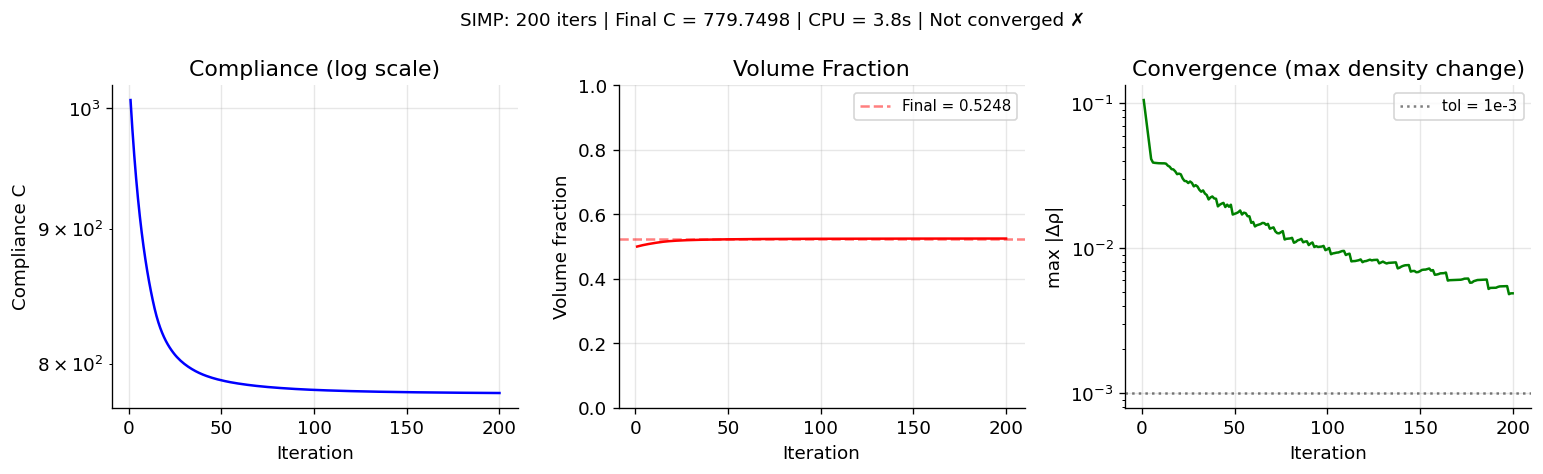

In [15]:
# ── MBB Results ─────────────────────────────────────────────────────────────────
plot_convergence(results_mbb)

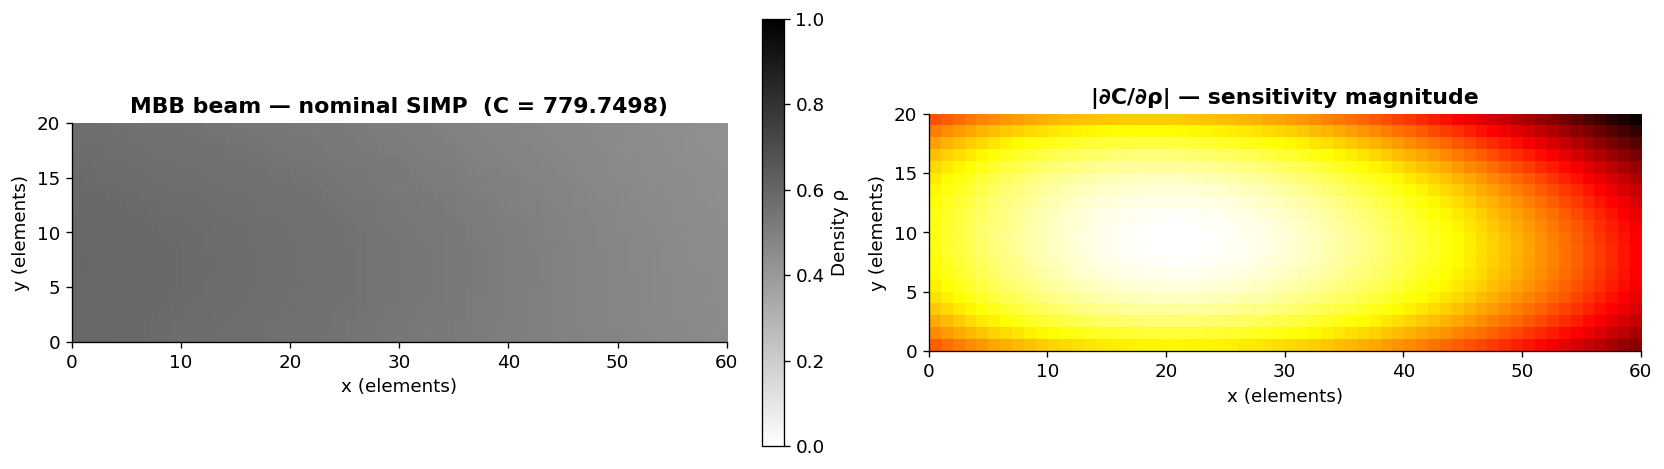

Final compliance : 779.749816
Final vol. frac. : 0.524796  (target 0.5)
Iterations       : 200


In [16]:
# ── MBB Topology ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_topology(
    results_mbb.final_state.density.rho,
    mesh_mbb,
    title=f"MBB beam — nominal SIMP  (C = {results_mbb.final_state.compliance:.4f})",
    ax=axes[0],
)

# Sensitivity field (magnitude, log scale)
sens = np.abs(results_mbb.final_state.sensitivity)
axes[1].imshow(
    sens.reshape(mesh_mbb.nelx, mesh_mbb.nely).T,
    cmap='hot', origin='lower', aspect='equal',
    extent=[0, mesh_mbb.nelx, 0, mesh_mbb.nely],
)
axes[1].set_title('|∂C/∂ρ| — sensitivity magnitude', fontweight='bold')
axes[1].set_xlabel('x (elements)')
axes[1].set_ylabel('y (elements)')

plt.tight_layout()
plt.show()

print(f"Final compliance : {results_mbb.final_state.compliance:.6f}")
print(f"Final vol. frac. : {results_mbb.final_state.density.volume_fraction:.6f}  (target {VOLFRAC_MBB})")
print(f"Iterations       : {results_mbb.iterations}")

---
## Test Case 2 — Cantilever Beam (60 × 40 elements, Vf = 0.4)

 Iter      Compliance    VolFrac       MaxΔρ
────────────────────────────────────────────
    1        309.8743   0.400000    0.069459
    5        294.1708   0.404833    0.032109
   10        281.0266   0.410026    0.030293
   15        271.5600   0.414526    0.032134
   20        264.2247   0.418451    0.033289
   25        258.8676   0.421537    0.030537
   30        255.4157   0.423615    0.027578
   35        253.0438   0.425089    0.025088
   40        251.3362   0.426178    0.022514
   45        250.0624   0.427006    0.020689
   50        249.0958   0.427647    0.018146
   55        248.3313   0.428158    0.017301
   60        247.7300   0.428566    0.016287
   65        247.2448   0.428899    0.014915
   70        246.8461   0.429176    0.013947
   75        246.5104   0.429409    0.013008
   80        246.2292   0.429603    0.012271
   85        245.9957   0.429770    0.011839
   90        245.7995   0.429910    0.010902
   95        245.6285   0.430035    0.011138
  100     

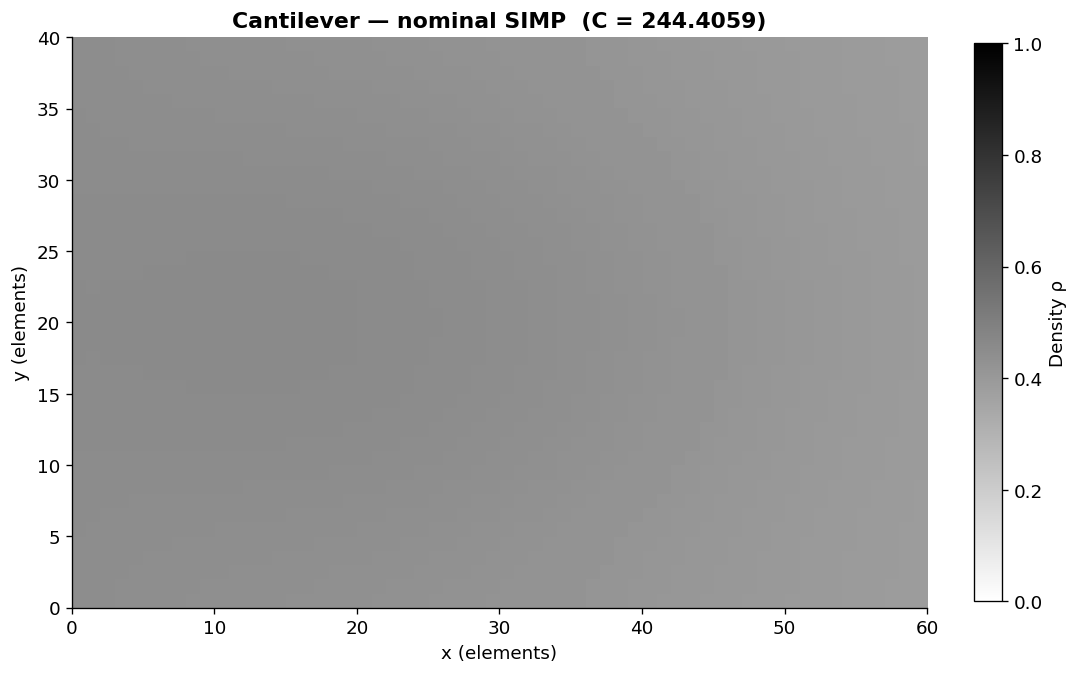

In [17]:
# ── Cantilever Beam Optimisation ────────────────────────────────────────────────
mesh_cant, prob_cant = make_cantilever_problem(
    nelx=60, nely=40,
    E0=1.0, nu=0.3, Emin=1e-9, penal=3.0,
)

results_cant = run_simp(
    mesh     = mesh_cant,
    problem  = prob_cant,
    volfrac  = 0.4,
    r_min    = 1.5,
    max_iter = 200,
    tol      = 1e-3,
    verbose  = True,
)

print(f"\nCPU time: {results_cant.cpu_time:.2f} s")

fig, ax = plt.subplots(figsize=(10, 7))
plot_topology(
    results_cant.final_state.density.rho,
    mesh_cant,
    title=f"Cantilever — nominal SIMP  (C = {results_cant.final_state.compliance:.4f})",
    ax=ax,
)
plt.show()

---
## Parameter Study: SIMP Penalty & Filter Radius

Two key SIMP parameters control result quality:

- **Penalty $p$** — higher $p$ drives densities toward 0/1 (crisper, but can cause local minima).  
  Recommended: $p = 3$; continuation from $p=1$ to $p=3$ can help for complex geometries.

- **Filter radius $r_{\min}$** — controls minimum feature size (larger → smoother, larger members).  
  Recommended: $\geq 1.5$ element lengths to reliably suppress checkerboards.

Running r_min sweep (60×20 MBB beam, Vf=0.5, p=3) ...
  r_min=1.2  →  C_final=706.4897  iters=150  converged=False
  r_min=1.5  →  C_final=780.3222  iters=150  converged=False
  r_min=2.5  →  C_final=883.0918  iters=150  converged=False
  r_min=4.0  →  C_final=935.0083  iters=150  converged=False


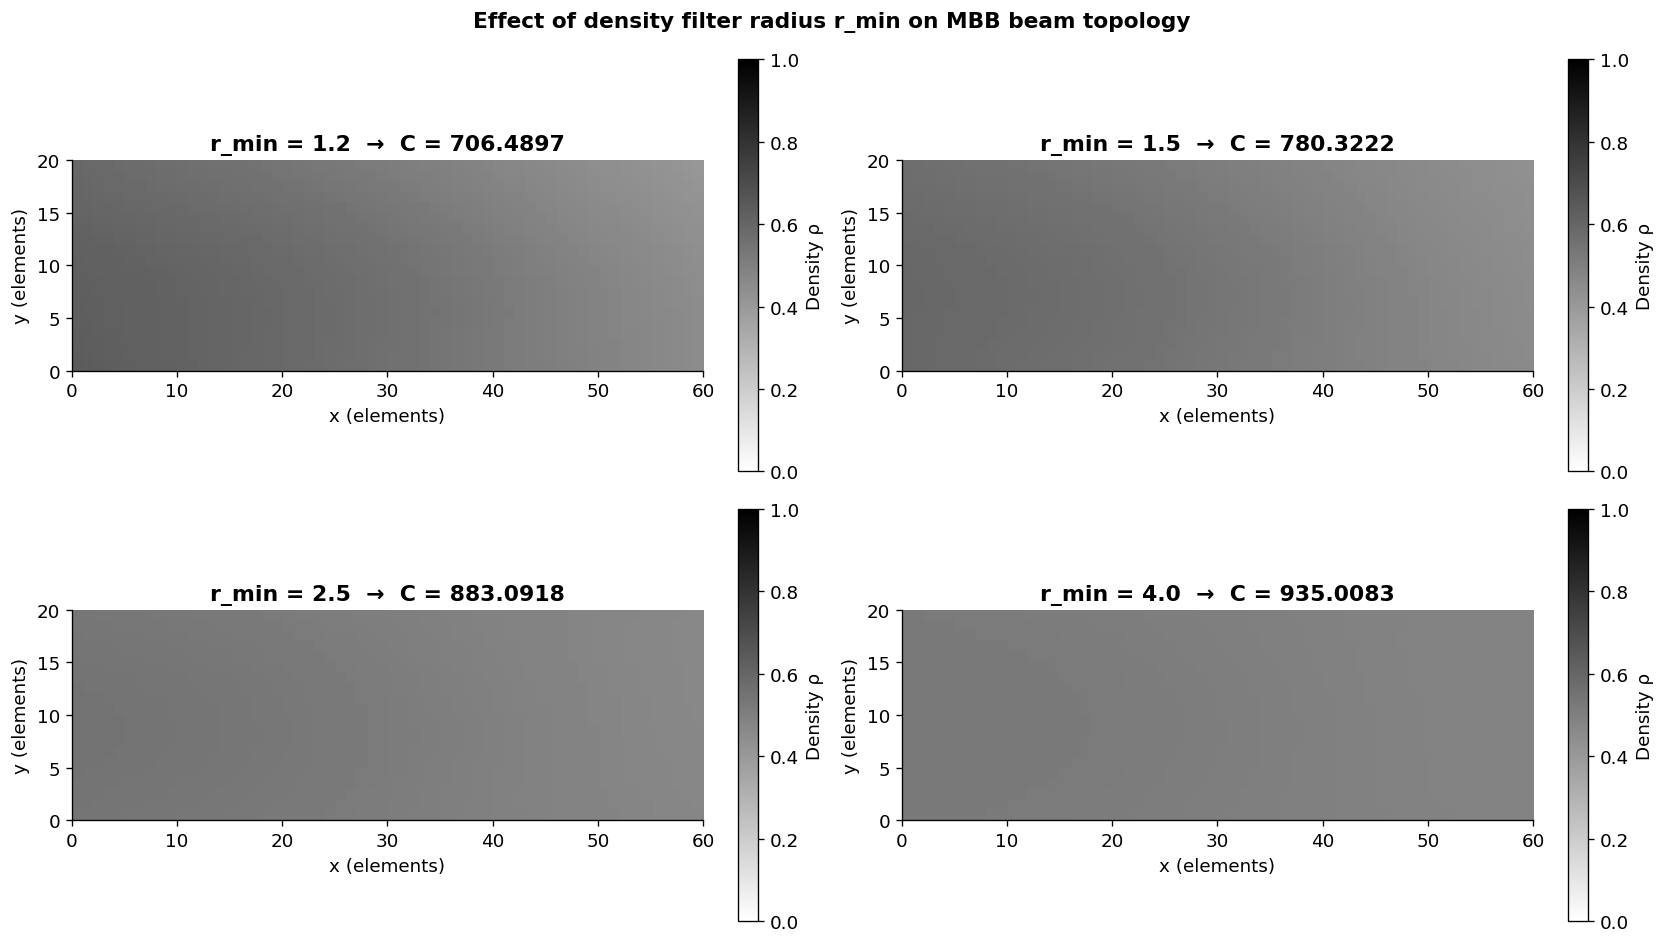

In [18]:
# ── Parameter Study: r_min sweep on MBB ────────────────────────────────────────
r_min_values = [1.2, 1.5, 2.5, 4.0]
param_results = {}

print("Running r_min sweep (60×20 MBB beam, Vf=0.5, p=3) ...")
for r in r_min_values:
    m, p = make_mbb_problem(nelx=60, nely=20)
    res  = run_simp(m, p, volfrac=0.5, r_min=r, max_iter=150, tol=1e-3, verbose=False)
    param_results[r] = res
    print(f"  r_min={r:.1f}  →  C_final={res.compliance_history[-1]:.4f}  "
          f"iters={res.iterations}  converged={res.converged}")

# Plot all topologies
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (r, res) in zip(axes.ravel(), param_results.items()):
    plot_topology(
        res.final_state.density.rho,
        m,                                  # all use same mesh size
        title=f"r_min = {r}  →  C = {res.compliance_history[-1]:.4f}",
        ax=ax,
    )

fig.suptitle("Effect of density filter radius r_min on MBB beam topology",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Running penal sweep (60×20 MBB beam, Vf=0.5, r_min=1.5) ...
  p=1.5  →  C=311.3013  grey=100.0%  iters=150
  p=2.0  →  C=422.3480  grey=100.0%  iters=150
  p=3.0  →  C=780.3222  grey=100.0%  iters=150
  p=4.0  →  C=1447.2189  grey=100.0%  iters=150


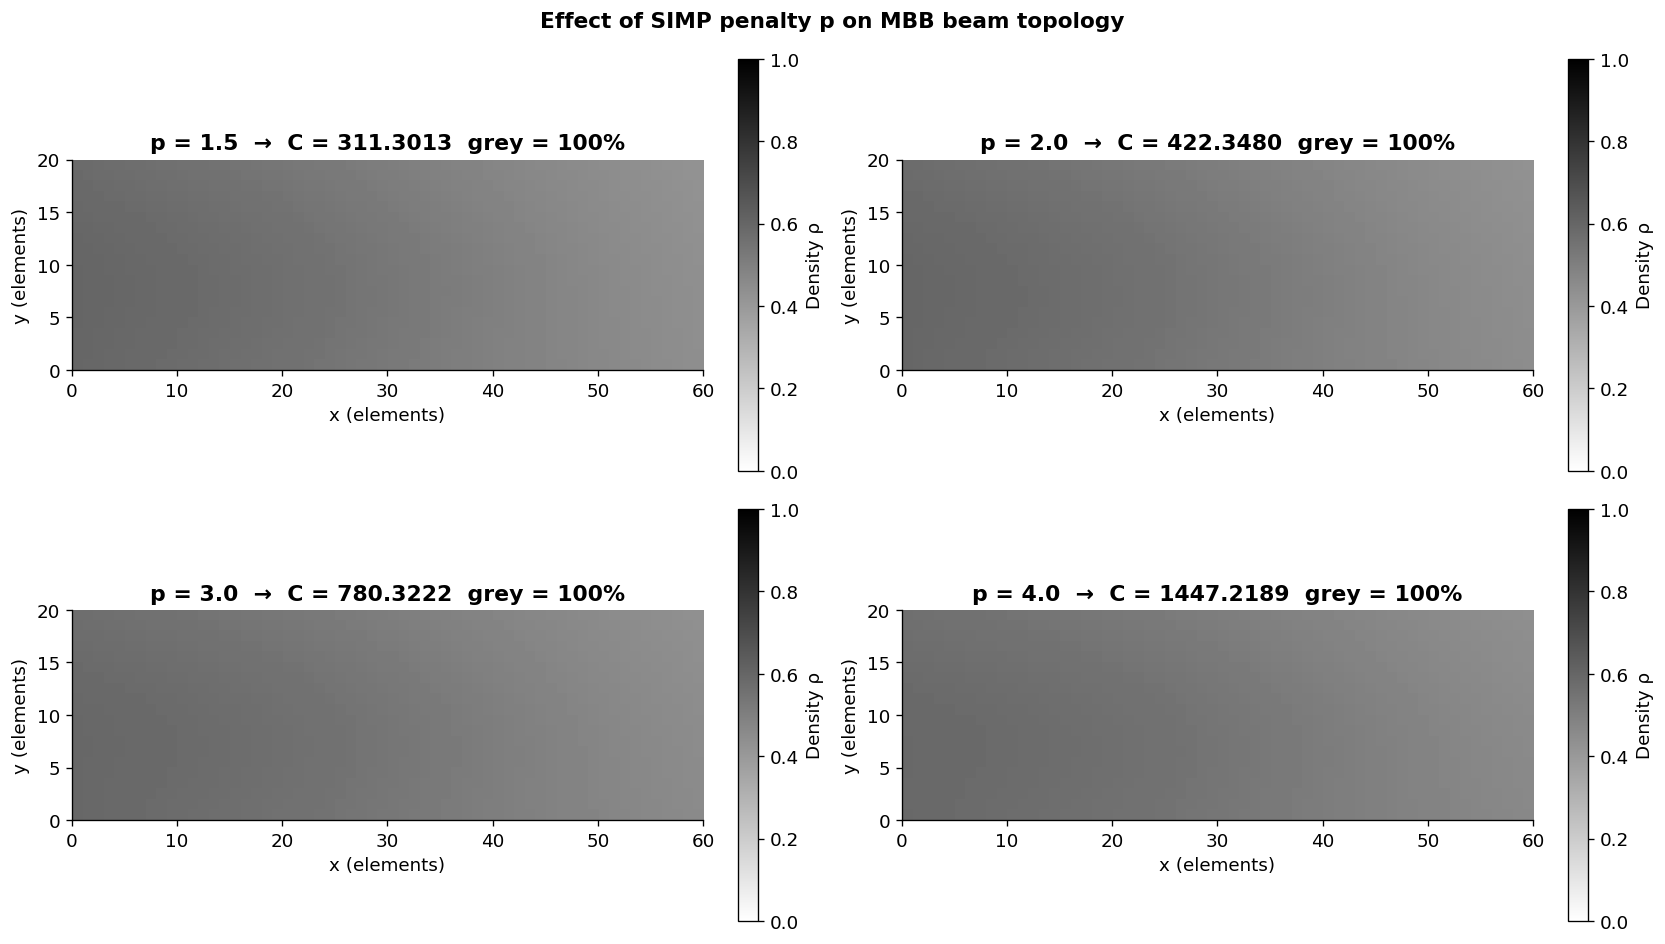

In [19]:
# ── Parameter Study: SIMP penalty p on MBB ────────────────────────────────────
penal_values = [1.5, 2.0, 3.0, 4.0]
penal_results = {}

print("Running penal sweep (60×20 MBB beam, Vf=0.5, r_min=1.5) ...")
for pen in penal_values:
    m, p = make_mbb_problem(nelx=60, nely=20, penal=pen)
    res  = run_simp(m, p, volfrac=0.5, r_min=1.5, max_iter=150, tol=1e-3, verbose=False)
    penal_results[pen] = res
    # Measure greyness: intermediate densities in (0.2, 0.8)
    rho  = res.final_state.density.rho
    grey = float(np.mean((rho > 0.2) & (rho < 0.8)) * 100)
    print(f"  p={pen:.1f}  →  C={res.compliance_history[-1]:.4f}  "
          f"grey={grey:.1f}%  iters={res.iterations}")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (pen, res) in zip(axes.ravel(), penal_results.items()):
    rho  = res.final_state.density.rho
    grey = float(np.mean((rho > 0.2) & (rho < 0.8)) * 100)
    plot_topology(
        rho, m,
        title=f"p = {pen}  →  C = {res.compliance_history[-1]:.4f}  grey = {grey:.0f}%",
        ax=ax,
    )

fig.suptitle("Effect of SIMP penalty p on MBB beam topology",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Penalisation Continuation

Starting with a low penalty $p=1$ (linear, convex problem) and gradually increasing to $p=3$
can help escape poor local minima and produce cleaner black-and-white designs.


── Stage  p = 1.5  (max 40 iters) ──────────────────
  iter    1  C = 356.0361  change = 0.1055
  iter   10  C = 328.9842  change = 0.0399
  iter   20  C = 318.2660  change = 0.0313
  iter   30  C = 314.9781  change = 0.0239
  iter   40  C = 313.5435  change = 0.0200

── Stage  p = 2.5  (max 40 iters) ──────────────────
  iter    1  C = 580.7874  change = 0.0254
  iter   10  C = 578.7186  change = 0.0197
  iter   20  C = 577.2620  change = 0.0170
  iter   30  C = 576.2764  change = 0.0164
  iter   40  C = 575.5950  change = 0.0140

── Stage  p = 3.0  (max 100 iters) ──────────────────
  iter    1  C = 783.7894  change = 0.0172
  iter   10  C = 782.8908  change = 0.0143
  iter   20  C = 782.1698  change = 0.0131
  iter   30  C = 781.6187  change = 0.0127
  iter   40  C = 781.2097  change = 0.0102
  iter   50  C = 780.8851  change = 0.0107
  iter   60  C = 780.6321  change = 0.0091
  iter   70  C = 780.4180  change = 0.0092
  iter   80  C = 780.2419  change = 0.0082
  iter   90  C = 780

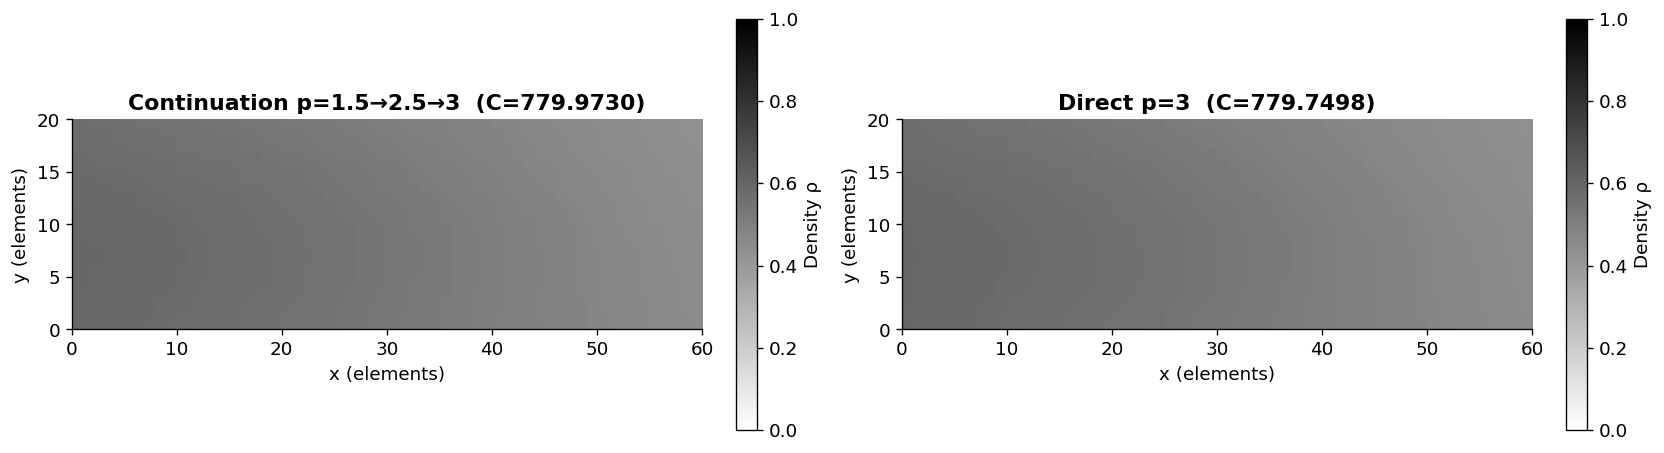

In [20]:
# ── Penalty Continuation: p = 1.5 → 2.0 → 3.0 ─────────────────────────────────

def run_simp_with_continuation(
    mesh:        Mesh2D,
    problem:     FEAProblem,
    volfrac:     float,
    r_min:       float,
    penal_steps: List[Tuple[float, int]] = ((1.5, 30), (2.5, 30), (3.0, 100)),
    tol:         float = 1e-3,
    verbose:     bool  = True,
) -> ResultsBundle:
    """
    SIMP with penalty continuation.

    penal_steps : list of (penalty, max_iters) pairs.
                  Design from one stage seeds the next.
    """
    from dataclasses import replace

    t0      = time.time()
    n_elem  = mesh.n_elements
    rho     = volfrac * np.ones(n_elem)     # uniform initialisation

    all_compliance, all_volume, all_change = [], [], []
    total_iters = 0

    edofs = mesh.all_element_dofs()
    H, Hs = build_filter_weights(mesh, r_min)

    for penal, max_it in penal_steps:
        # Swap penalty in problem (create new FEAProblem with updated penal)
        prob_stage = FEAProblem(
            mesh=mesh, E0=problem.E0, Emin=problem.Emin,
            nu=problem.nu, penal=penal,
            fixed_dofs=problem.fixed_dofs, free_dofs=problem.free_dofs,
            force_vector=problem.force_vector,
        )
        k0 = compute_q4_stiffness(1.0, prob_stage.nu)

        if verbose:
            print(f"\n── Stage  p = {penal}  (max {max_it} iters) ──────────────────")

        C, dc, U = 0.0, np.zeros(n_elem), np.zeros(mesh.n_dofs)
        change = 1.0

        for it in range(1, max_it + 1):
            rho_prev = rho.copy()
            rho_phys = apply_density_filter(rho, H, Hs)

            K = assemble_stiffness(mesh, prob_stage, rho_phys, edofs, k0)
            U = solve_fea(K, prob_stage)

            C, dc_phys = compute_compliance_and_sensitivity(U, prob_stage, rho_phys, edofs, k0)
            dc         = filter_sensitivity_chain_rule(dc_phys, H, Hs)
            rho        = oc_update(rho, dc, volfrac)

            change = float(np.max(np.abs(rho - rho_prev)))
            all_compliance.append(C)
            all_volume.append(float(rho_phys.mean()))
            all_change.append(change)
            total_iters += 1

            if verbose and (it % 10 == 0 or it == 1):
                print(f"  iter {it:>4}  C = {C:.4f}  change = {change:.4f}")

            if change < tol and it >= 5:
                if verbose:
                    print(f"  ✓ Stage converged at iter {it}")
                break

    final = DesignState(
        iteration    = total_iters,
        density      = DensityField(rho=rho_phys, rho_unfiltered=rho),
        compliance   = C,
        displacement = U,
        sensitivity  = dc,
        change       = change,
    )
    return ResultsBundle(
        final_state        = final,
        compliance_history = all_compliance,
        volume_history     = all_volume,
        change_history     = all_change,
        iterations         = total_iters,
        converged          = change < tol,
        cpu_time           = time.time() - t0,
    )


# Run with continuation
mesh_c, prob_c = make_mbb_problem(nelx=60, nely=20, penal=1.5)   # penal overridden per stage
results_cont = run_simp_with_continuation(
    mesh=mesh_c,
    problem=prob_c,
    volfrac=0.5,
    r_min=1.5,
    penal_steps=[(1.5, 40), (2.5, 40), (3.0, 100)],
    verbose=True,
)

# Compare with direct p=3
m_d, p_d = make_mbb_problem(nelx=60, nely=20, penal=3.0)
results_direct = run_simp(m_d, p_d, volfrac=0.5, r_min=1.5, max_iter=200, tol=1e-3, verbose=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_topology(
    results_cont.final_state.density.rho, mesh_c,
    title=f"Continuation p=1.5→2.5→3  (C={results_cont.final_state.compliance:.4f})",
    ax=axes[0],
)
plot_topology(
    results_direct.final_state.density.rho, m_d,
    title=f"Direct p=3  (C={results_direct.final_state.compliance:.4f})",
    ax=axes[1],
)
plt.tight_layout()
plt.show()

---
## Summary: Module Outputs Produced

| Module | Key output |
|--------|------------|
| **2** | `Mesh2D`, `FEAProblem`, `DensityField`, `DesignState`, `ResultsBundle` |
| **4** | `U` displacement field, `C` compliance, `dc` sensitivity |
| **5** | Optimal density field `ρ*`, convergence histories, CPU time |

### Checklist before moving to Module 6

- [ ] SIMP converges and produces recognisable truss/shell topology
- [ ] Volume fraction stays within tolerance of target ($|V_f - V_f^*| < 10^{-4}$)
- [ ] Element stiffness matrix has exactly 3 near-zero eigenvalues (rigid body modes)
- [ ] Compliance decreases monotonically (with density filter; slight non-monotone behaviour is expected with sensitivity filter)
- [ ] `ResultsBundle` serialises correctly (can be pickled / written to YAML for the CLI)

### Key hyperparameters to hand to the downstream pipeline

```yaml
simp:
  penal:    3.0      # SIMP penalty (or final value after continuation)
  r_min:    1.5      # filter radius in element units
  volfrac:  0.50     # target volume fraction Vf
  move:     0.20     # OC move limit
  tol:      1.0e-3   # convergence tolerance on max |Δρ|
  max_iter: 200
  continuation:
    enabled: true
    stages:  [[1.5, 40], [2.5, 40], [3.0, 100]]
```

### Next: Module 6 — Metrology Data Ingestion

The `ResultsBundle.final_state.density.rho` array (the nominal optimal design) is the **warm-start
input** to the robust optimiser (Module 17). Before that, Modules 6–12 characterise the
manufacturing process uncertainty: raw CMM point clouds → covariance kernel → KL expansion →
PCE surrogate.